# Exercise Graph V

In [7]:
from typing import TypedDict, List
import random
from langgraph.graph import StateGraph, END

In [11]:
class AgentState(TypedDict):
    player_name : str
    guesses : List[int]
    attempts : int
    lower_bound: int
    upper_bound : int

In [13]:
def setup(state: AgentState) -> AgentState:
    state["player_name"] = f"Hi there, {state["player_name"]}"
    state["attempts"] = 0
    return state

def guess(state: AgentState) -> AgentState:
    """This is function for generating number random while this function is calling"""
    state["guesses"].append(random.randint(state["lower_bound"], state["upper_bound"]))
    state["attempts"] += 1
    return state

def hint_node(state: AgentState) -> AgentState:
    if state["attempts"] < 7:
        return "continue"
    else:
        return "exit"

In [16]:
graph = StateGraph(AgentState)

graph.add_node("setup", setup)
graph.add_node("guess", guess)
graph.add_node("hint_node", lambda x:x)
graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint_node")

graph.add_conditional_edges(
    "hint_node",
    hint_node,
    {
        "continue" : "guess",
        "exit" : END 
    }
)

graph.set_entry_point("setup")

app = graph.compile()

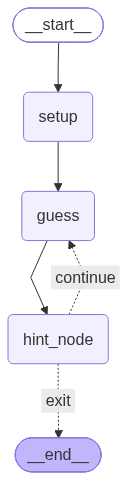

In [17]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [18]:
result = app.invoke({"player_name" : "Student", "guesses" : [], "attempts" : 0, "lower_bound" : 1, "upper_bound" : 20})
print(result)

{'player_name': 'Hi there, Student', 'guesses': [10, 12, 10, 2, 10, 7, 13], 'attempts': 7, 'lower_bound': 1, 'upper_bound': 20}
